In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df = pd.read_csv("data/behaviour_data.csv")

In [5]:
df

,timestamp,name,mousePointsCount,avgSpeed,speedStdDev,accelStdDev,jitterCount,angleStd,diffScore,overshootBeforeClick,hoverTime,hesitation,clickLatency,clickOffset,typingStdDev,interActionGapAvg,pageFocusLost,isChecked
0,1767289694905,BotUser,60,0.149797,0.136283,0.070561,6,1.266098,1.696464,0,1368,18,0,43.900409,0,0,False,True
1,1767289727084,Kashish Jaiswal,80,0.835084,2.135536,1.233340,34,2.400265,0.750825,0,0,26937,0,43.741713,0,0,False,True
2,1767291684539,Kashish Jaiswal,85,0.247432,0.311433,0.256825,32,1.722361,1.294357,0,0,1033,0,41.879506,0,0,False,True
3,1767291698229,Kashish Jaiswal,84,0.243080,0.436254,0.411389,35,1.649806,6.507215,0,0,423,0,38.358017,0,0,False,True
4,1767296105859,BotUser,73,0.541225,1.247459,1.483211,10,1.156635,1.779016,0,767,13,0,41.724643,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,1767362569388,kashish,190,0.785889,2.003231,1.496597,48,0.551324,0.436499,0,301,308,994,161.723996,0,0,False,True
87,1767362930634,BotUser,63,0.079527,0.045105,0.035410,2,0.638281,1.801996,0,0,20,0,188.982200,0,0,False,True
88,1767363250533,BotUser,61,0.095876,0.075590,0.099861,2,0.706057,1.253811,0,0,12,0,188.434795,0,0,False,True
89,1767363277766,BotUser,61,0.110147,0.065671,0.038735,0,0.504862,0.265524,0,0,1066,0,187.471790,0,0,False,True


In [6]:
df["name"].value_counts()

name
BotUser             44
kashish             22
Kashish Jaiswal     11
Kashish Jaiswal1     2
jaiswal              2
dhanish              1
khsk                 1
Kashish              1
kashsih              1
Untitled             1
ashsihs              1
user                 1
human                1
huamn                1
kashish jaiswal      1
Name: count, dtype: int64

In [7]:
df["label"] = (df["name"]!="BotUser").astype(int)

In [8]:
df

,timestamp,name,mousePointsCount,avgSpeed,speedStdDev,accelStdDev,jitterCount,angleStd,diffScore,overshootBeforeClick,hoverTime,hesitation,clickLatency,clickOffset,typingStdDev,interActionGapAvg,pageFocusLost,isChecked,label
0,1767289694905,BotUser,60,0.149797,0.136283,0.070561,6,1.266098,1.696464,0,1368,18,0,43.900409,0,0,False,True,0
1,1767289727084,Kashish Jaiswal,80,0.835084,2.135536,1.233340,34,2.400265,0.750825,0,0,26937,0,43.741713,0,0,False,True,1
2,1767291684539,Kashish Jaiswal,85,0.247432,0.311433,0.256825,32,1.722361,1.294357,0,0,1033,0,41.879506,0,0,False,True,1
3,1767291698229,Kashish Jaiswal,84,0.243080,0.436254,0.411389,35,1.649806,6.507215,0,0,423,0,38.358017,0,0,False,True,1
4,1767296105859,BotUser,73,0.541225,1.247459,1.483211,10,1.156635,1.779016,0,767,13,0,41.724643,0,0,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,1767362569388,kashish,190,0.785889,2.003231,1.496597,48,0.551324,0.436499,0,301,308,994,161.723996,0,0,False,True,1
87,1767362930634,BotUser,63,0.079527,0.045105,0.035410,2,0.638281,1.801996,0,0,20,0,188.982200,0,0,False,True,0
88,1767363250533,BotUser,61,0.095876,0.075590,0.099861,2,0.706057,1.253811,0,0,12,0,188.434795,0,0,False,True,0
89,1767363277766,BotUser,61,0.110147,0.065671,0.038735,0,0.504862,0.265524,0,0,1066,0,187.471790,0,0,False,True,0


In [9]:
df["label"].value_counts(normalize = True)*100

label
1    51.648352
0    48.351648
Name: proportion, dtype: float64

In [11]:
df.drop(columns = ["timestamp","name","overshootBeforeClick","typingStdDev","interActionGapAvg","pageFocusLost"],inplace = True)

In [12]:
df

,mousePointsCount,avgSpeed,speedStdDev,accelStdDev,jitterCount,angleStd,diffScore,hoverTime,hesitation,clickLatency,clickOffset,isChecked,label
0,60,0.149797,0.136283,0.070561,6,1.266098,1.696464,1368,18,0,43.900409,True,0
1,80,0.835084,2.135536,1.233340,34,2.400265,0.750825,0,26937,0,43.741713,True,1
2,85,0.247432,0.311433,0.256825,32,1.722361,1.294357,0,1033,0,41.879506,True,1
3,84,0.243080,0.436254,0.411389,35,1.649806,6.507215,0,423,0,38.358017,True,1
4,73,0.541225,1.247459,1.483211,10,1.156635,1.779016,767,13,0,41.724643,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,190,0.785889,2.003231,1.496597,48,0.551324,0.436499,301,308,994,161.723996,True,1
87,63,0.079527,0.045105,0.035410,2,0.638281,1.801996,0,20,0,188.982200,True,0
88,61,0.095876,0.075590,0.099861,2,0.706057,1.253811,0,12,0,188.434795,True,0
89,61,0.110147,0.065671,0.038735,0,0.504862,0.265524,0,1066,0,187.471790,True,0


In [14]:
df.isnull().sum()

mousePointsCount    0
avgSpeed            0
speedStdDev         0
accelStdDev         0
jitterCount         0
angleStd            0
diffScore           0
hoverTime           0
hesitation          0
clickLatency        0
clickOffset         0
isChecked           0
label               0
dtype: int64

In [15]:
df.describe()

,mousePointsCount,avgSpeed,speedStdDev,accelStdDev,jitterCount,angleStd,diffScore,hoverTime,hesitation,clickLatency,clickOffset,label
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,9.100000e+01,91.000000,91.000000,91.000000
mean,125.857143,0.419393,0.749252,0.525125,33.340659,0.880706,1.595429,560.164835,1.166480e+05,216.164835,64.466776,0.516484
std,104.931890,0.339141,0.783681,0.635478,36.405195,0.358605,1.115685,713.108380,1.085333e+06,664.099595,44.964509,0.502497
min,32.000000,0.034848,0.017207,0.021786,0.000000,0.343494,0.265524,0.000000,2.000000e+00,0.000000,29.984926,0.000000
25%,62.000000,0.152151,0.135789,0.074728,8.500000,0.637492,0.872002,0.000000,1.500000e+01,0.000000,41.919182,0.000000
50%,93.000000,0.247432,0.311433,0.229590,26.000000,0.783741,1.303252,0.000000,2.100000e+01,0.000000,43.689190,1.000000
75%,137.000000,0.635899,1.315152,0.844197,48.000000,1.104252,1.936859,1059.000000,3.400000e+02,0.000000,52.318582,1.000000
max,676.000000,1.219891,3.666733,4.482013,224.000000,2.400265,6.507215,3217.000000,1.035565e+07,4567.000000,188.982200,1.000000


UNIVARIANT ANALYSIS

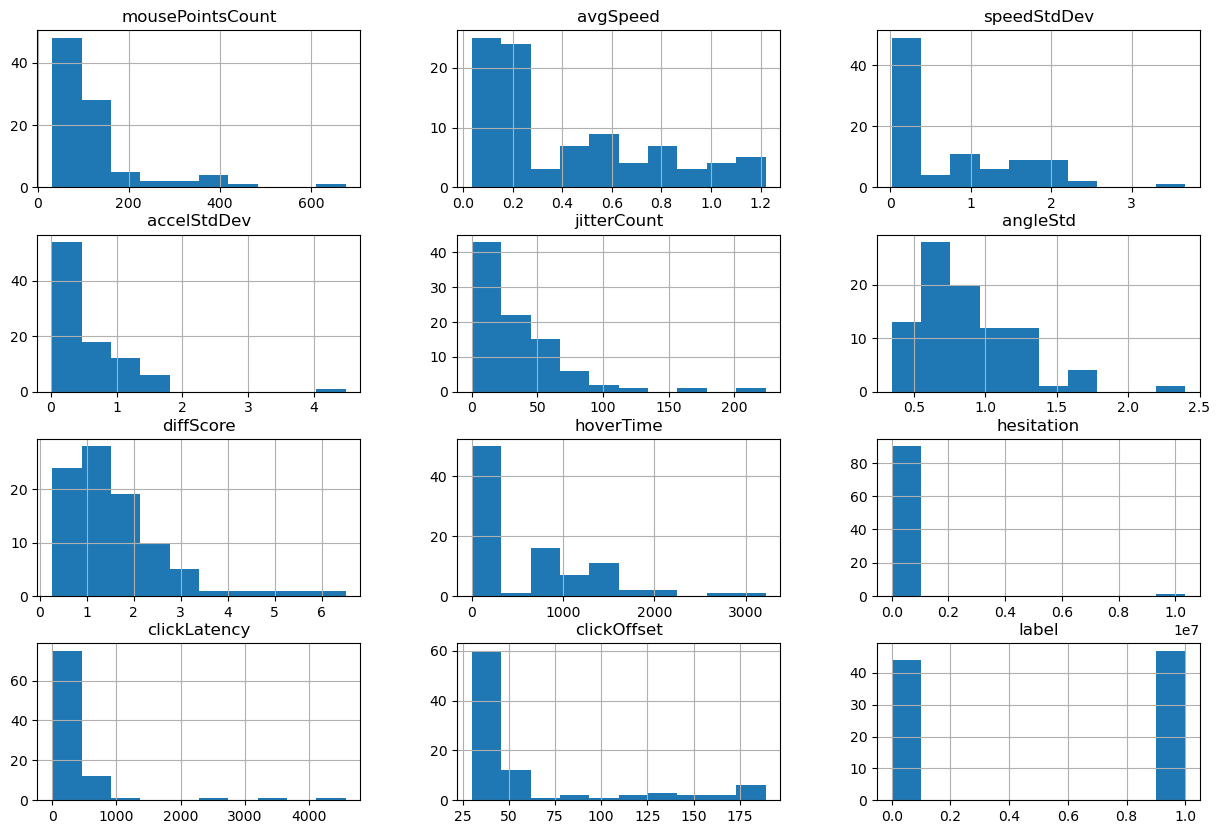

In [18]:
df.hist(figsize=(15,10))
plt.show()

<Axes: xlabel='label', ylabel='count'>

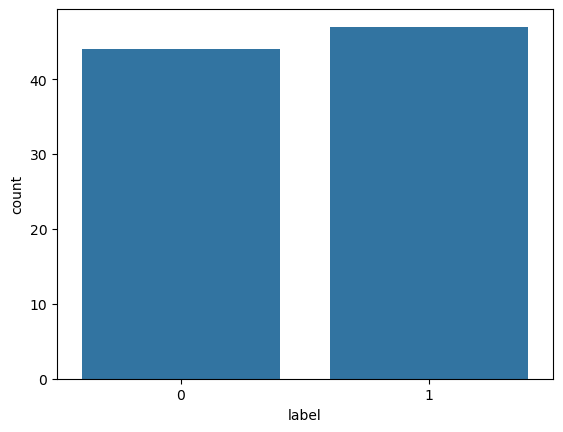

In [19]:
sns.countplot(x = df["label"],data = df)

(array([43., 22., 15.,  6.,  2.,  1.,  0.,  1.,  0.,  1.]),
 array([  0. ,  22.4,  44.8,  67.2,  89.6, 112. , 134.4, 156.8, 179.2,
        201.6, 224. ]),
 <BarContainer object of 10 artists>)

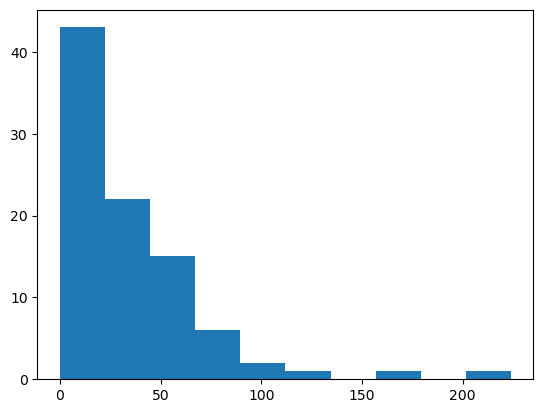

In [20]:
plt.hist(df["jitterCount"])

<Axes: ylabel='jitterCount'>

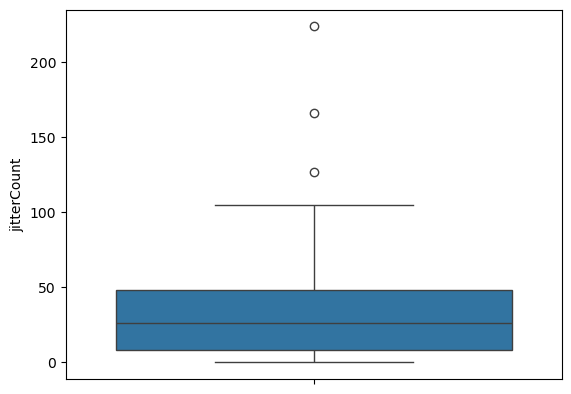

In [21]:
sns.boxplot(df['jitterCount'])

BIVARIANT ANALYSIS

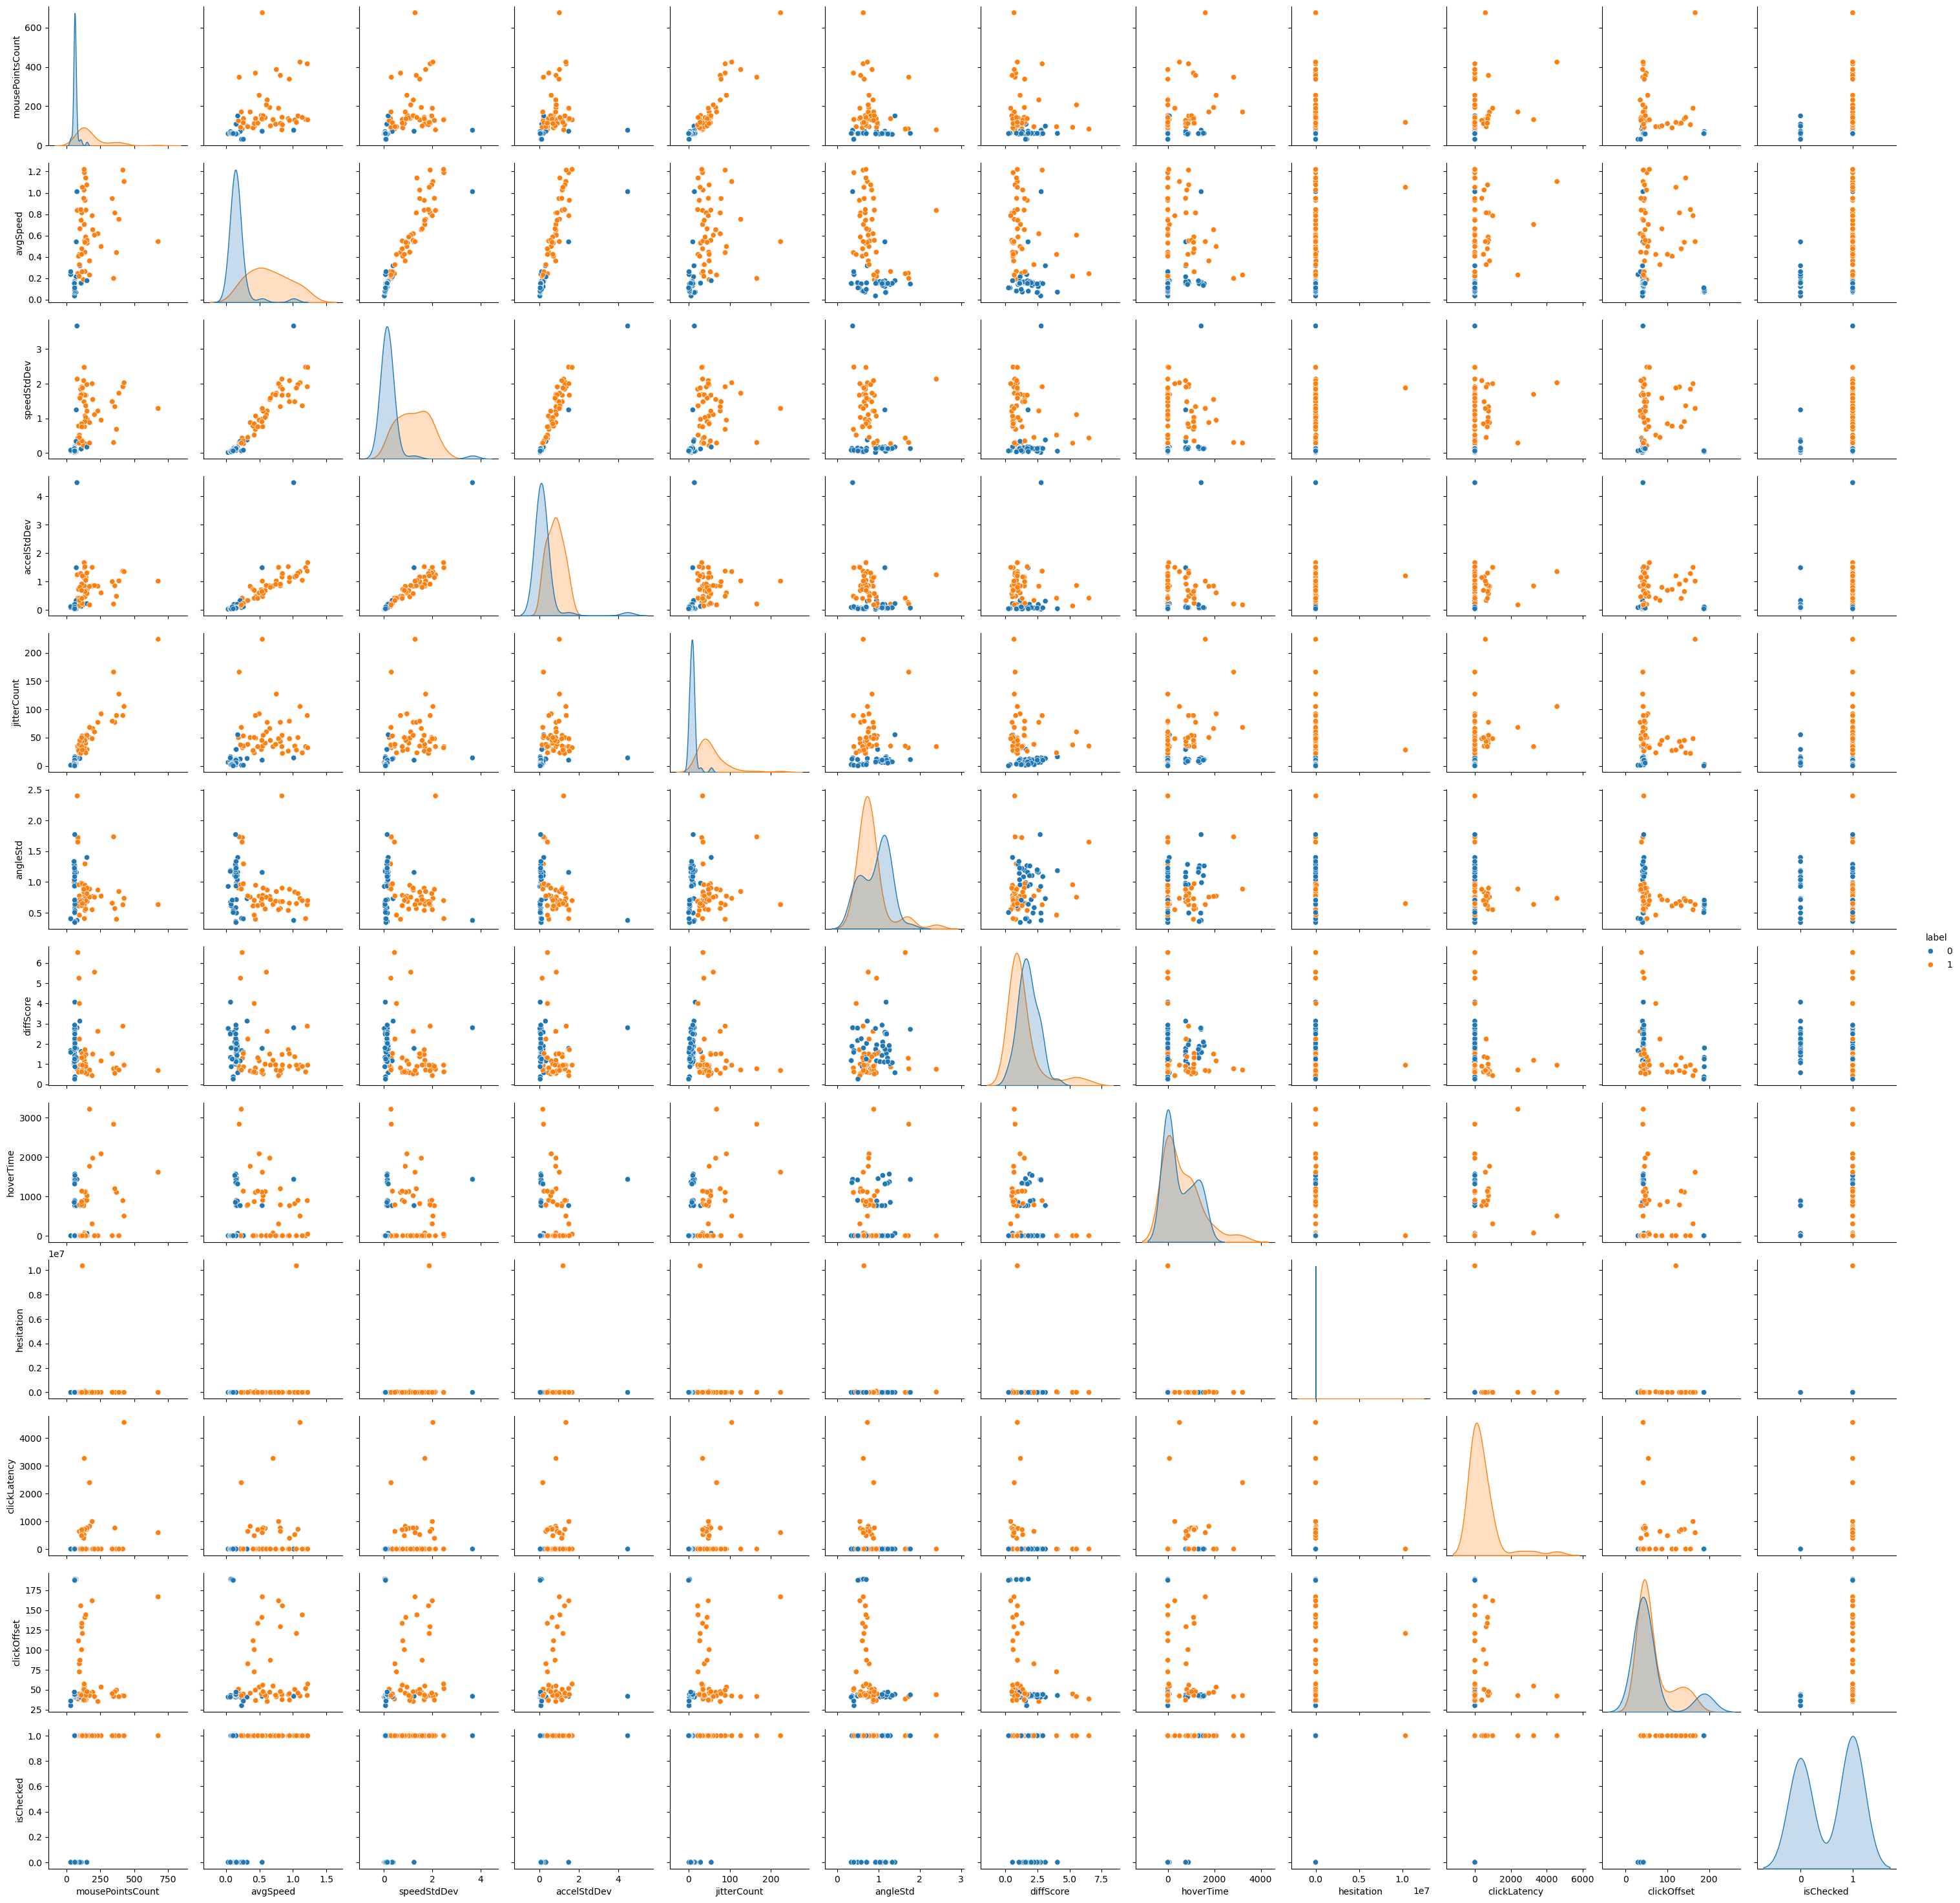

In [22]:
sns.pairplot(df,hue = 'label')